# A* Search on a Grid

A* ranks a candidate by the cost already paid plus an estimate of the remaining cost: $f(n) = g(n) + h(n)$. This example uses unit-cost moves in four directions and Manhattan distance.

Run the cells in order with NumPy and Matplotlib installed. The map helpers mirror the BFS/DFS notebook, so the main change is how the frontier chooses its next path.


## Imports and Grid Symbols

The array stores walls as <code>"#"</code> and open cells as <code>"."</code>. Positions are <code>(row, column)</code> tuples. The figure size controls only the display, not the search space.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

WALL = "#"
EMPTY = "."

figure_size = 5



## Generate the Map

The generator samples walls, opens a cell in each completely blocked 2-by-2 patch, and uses a **union-find** structure to identify connected regions. A cell's one-dimensional index is <code>row * width + column</code>.

The nested <code>find</code> follows parent links and shortens paths; <code>union</code> joins two roots. The final scan removes walls separating different neighboring regions. This is map preparation, not A* itself. For the data structure, see [Princeton's union-find introduction](https://algs4.cs.princeton.edu/15uf/).


In [ ]:
def generate_map(width, height, seed):
    np.random.seed(seed)
    m = np.random.choice([WALL, EMPTY], size=(height, width))
    # scan all 2x2 blocks and remove walls that are not needed
    for i in range(height - 1):
        for j in range(width - 1):
            block = m[i : i + 2, j : j + 2]
            if np.sum(block == WALL) == 4:
                # randomly remove one wall
                block[np.random.randint(2), np.random.randint(2)] = EMPTY
    # run union-find to make sure the map is connected
    parent = np.arange(width * height)

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return parent[x]

    def union(x, y):
        parent[find(x)] = find(y)

    for i in range(height):
        for j in range(width):
            if m[i, j] == WALL:
                continue
            for ni, nj in [(i + 1, j), (i, j + 1)]:
                if ni < height and nj < width and m[ni, nj] == EMPTY:
                    union(i * width + j, ni * width + nj)
    for i in range(height):
        for j in range(width):
            if m[i, j] == WALL:
                # check if all neighbors of this wall are connected
                # if not, remove this wall
                neighbors = []
                for ni, nj in [(i + 1, j), (i - 1, j), (i, j + 1), (i, j - 1)]:
                    if 0 <= ni < height and 0 <= nj < width and m[ni, nj] == EMPTY:
                        neighbors.append(
                            find(ni * width + nj)
                        )  # get the parent of all empty neighbors
                if len(neighbors) != 0 and len(set(neighbors)) != 1:
                    m[i, j] = EMPTY
                    # connect all neighbors
                    for k in range(1, len(neighbors)):
                        union(neighbors[k - 1], neighbors[k])
    return m




## Select Start and Goal

The function resamples until both chosen cells are open. It does not require different endpoints or independently check that a path connects them. Search still needs to handle the actual map it receives.


In [ ]:
def find_start_end(m):
    # randomly find a start and end point
    h, w = m.shape
    start = np.random.randint(h), np.random.randint(w)
    end = np.random.randint(h), np.random.randint(w)
    while m[start] == WALL or m[end] == WALL:
        start = np.random.randint(h), np.random.randint(w)
        end = np.random.randint(h), np.random.randint(w)
    return start, end




## Draw the Grid

Each array cell becomes a rectangle. The drawing flips the vertical coordinate because array rows increase downward, while plot coordinates increase upward. Pass an existing Matplotlib axes object as <code>ax</code>.


In [ ]:
def show_map(m, ax=None):
    h, w = m.shape
    for i in range(h):
        for j in range(w):
            # draw a rectangle
            ax.add_patch(
                plt.Rectangle(
                    (j, h - i - 1), 1, 1, fc="gray" if m[i, j] == WALL else "white"
                )
            )
            # draw the border
            ax.add_patch(
                plt.Rectangle((j, h - i - 1), 1, 1, fill=False, edgecolor="black")
            )
    # draw indices of horizontal and vertical axis
    for i in range(h):
        ax.text(-0.5, h - i - 0.5, str(i), ha="center", va="center")
    for j in range(w):
        ax.text(j + 0.5, h + 0.5, str(j), ha="center", va="center")
    ax.set_xlim(-0.3, w + 0.3)
    ax.set_ylim(-0.3, h + 0.3)
    ax.set_aspect("equal", adjustable="box")
    ax.axis("off")




## Draw a Returned Path

The first cell is green, the final cell is red, and line segments connect consecutive positions. This helper expects a nonempty path; it does not handle a failed search result of <code>None</code>.


In [ ]:
def draw_path(m, path, ax):
    h, w = m.shape
    last = path[0]
    show_map(m, ax)
    # draw the start and end points by filling the grid with a different color
    ax.add_patch(plt.Rectangle((last[1], h - last[0] - 1), 1, 1, fc="green"))
    ax.add_patch(plt.Rectangle((path[-1][1], h - path[-1][0] - 1), 1, 1, fc="red"))
    for i, j in path[1:]:
        # connect the two points
        ax.plot([last[1] + 0.5, j + 0.5], [h - last[0] - 0.5, h - i - 0.5], "r", lw=2)
        last = (i, j)




## Build the Example

The seed reproduces this 15-column, 10-row map. Green and red circles mark the start and goal. Count the row and column displacement between them before considering the walls.


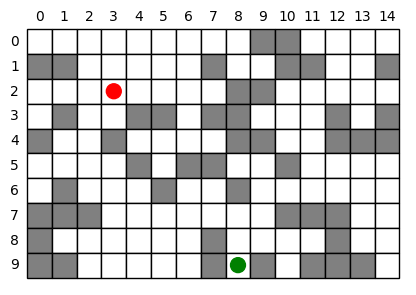

In [ ]:
a = generate_map(15, 10, 1)
start, end = find_start_end(a)
# create a figure
fig, ax = plt.subplots(figsize=(figure_size, figure_size))
show_map(a, ax)
# plot the start and end points
ax.add_patch(
    plt.Circle((start[1] + 0.5, a.shape[0] - start[0] - 0.5), 0.3, color="green")
)
ax.add_patch(plt.Circle((end[1] + 0.5, a.shape[0] - end[0] - 0.5), 0.3, color="red"))
plt.show()

## Manhattan-Distance Heuristic

For positions $(r_1,c_1)$ and $(r_2,c_2)$, $h = |r_1-r_2| + |c_1-c_2|$. With four-direction, unit-cost movement, every route must cover that displacement. Walls can force extra moves but cannot make a shorter route, so the estimate is admissible.

The estimate is also consistent: crossing one edge changes Manhattan distance by at most that edge's cost. Diagonal moves or different edge costs would require reconsidering this heuristic.


In [ ]:
import heapq

# A* algorithm
def heuristic(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1]) # Manhattan distance



## Expand the Lowest Estimated Total Cost

Each heap entry contains <code>(f, position, path)</code>. The stored path excludes its current position. Extending it adds the current position, making <code>len(new_path)</code> the cost of reaching the neighbor. The goal is tested when its entry is removed.

This compact version is **tree search over paths**: it has no best-cost dictionary or closed set. The same grid cell can therefore appear many times, including via cycles. An unreachable goal can lead to unbounded repeated exploration. A scalable graph-search version should track the best known <code>g</code> for each state and skip inferior entries.

Blue circles show entries in the frontier. The frame is drawn before the next heap removal, so the green circle still shows the previously selected position.


In [ ]:
def astar(m, start, end):
    h, w = m.shape
    open_list = [(0, start, [])] # f, pos, path
    pos = start
    heapq.heapify(open_list)
    while open_list:
        # draw the current position and all elements in the open list
        fig, ax = plt.subplots(figsize=(figure_size, figure_size))
        show_map(m, ax)
        ax.add_patch(plt.Circle((pos[1] + 0.5, h - pos[0] - 0.5), 0.3, color="green"))
        ax.add_patch(plt.Circle((end[1] + 0.5, a.shape[0] - end[0] - 0.5), 0.3, color="red"))
        for _, p, _ in open_list:
            ax.add_patch(plt.Circle((p[1] + 0.5, h - p[0] - 0.5), 0.1, color="blue"))
        plt.show()

        f, pos, path = heapq.heappop(open_list)
        print(f, pos, path)

        if pos == end:
            return path + [pos]
        for i, j in [(1, 0), (-1, 0), (0, 1), (0, -1)]:
            ni, nj = pos[0] + i, pos[1] + j
            if 0 <= ni < h and 0 <= nj < w and m[ni, nj] == EMPTY:
                new_path = path + [pos]
                heapq.heappush(open_list, (len(new_path) + heuristic((ni, nj), end), (ni, nj), new_path))
    return None



## Run and Read the Trace

Each printed line gives the popped priority, position, and path prefix. The final plot overlays the returned route. Its number of moves is <code>len(path) - 1</code>, not the number of cells in the list.

The saved example reaches the goal. Keep that distinction separate from the implementation's limitation on unreachable maps.


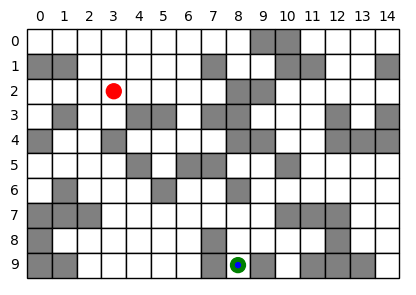

0 (9, 8) []


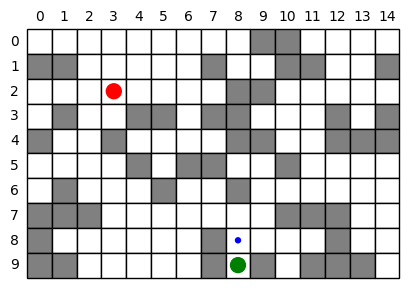

12 (8, 8) [(9, 8)]


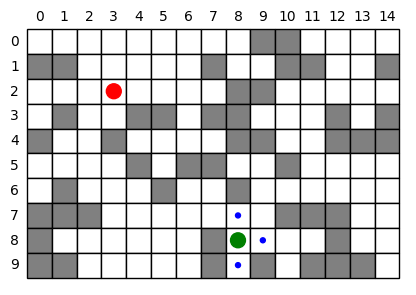

12 (7, 8) [(9, 8), (8, 8)]


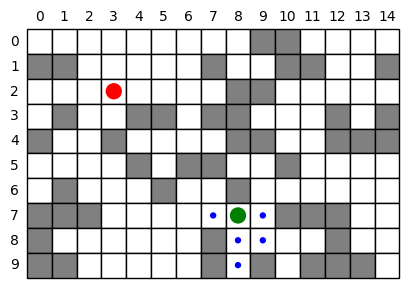

12 (7, 7) [(9, 8), (8, 8), (7, 8)]


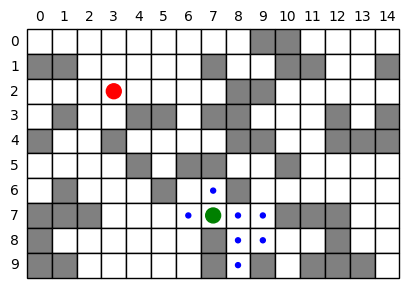

12 (6, 7) [(9, 8), (8, 8), (7, 8), (7, 7)]


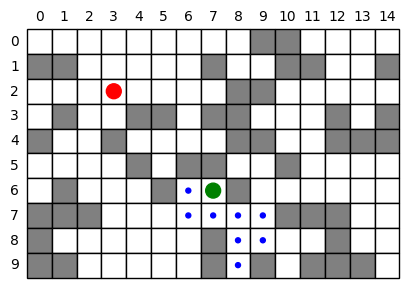

12 (6, 6) [(9, 8), (8, 8), (7, 8), (7, 7), (6, 7)]


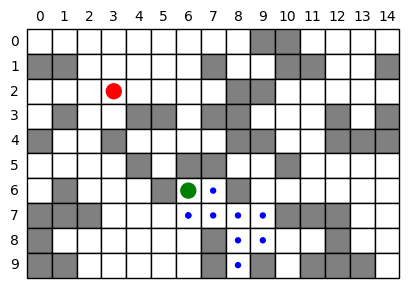

12 (7, 6) [(9, 8), (8, 8), (7, 8), (7, 7)]


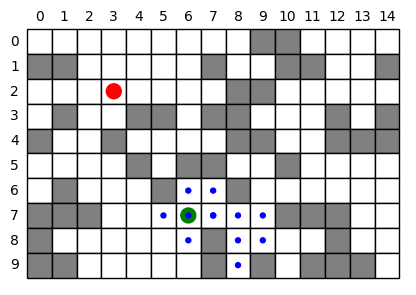

12 (6, 6) [(9, 8), (8, 8), (7, 8), (7, 7), (7, 6)]


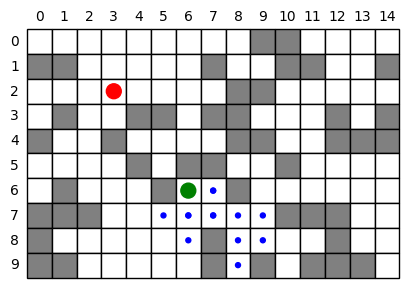

12 (7, 5) [(9, 8), (8, 8), (7, 8), (7, 7), (7, 6)]


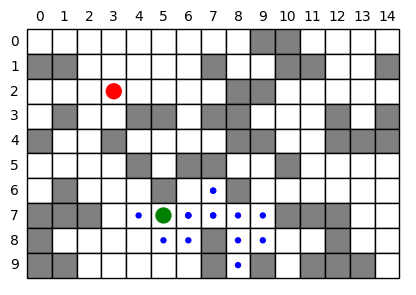

12 (7, 4) [(9, 8), (8, 8), (7, 8), (7, 7), (7, 6), (7, 5)]


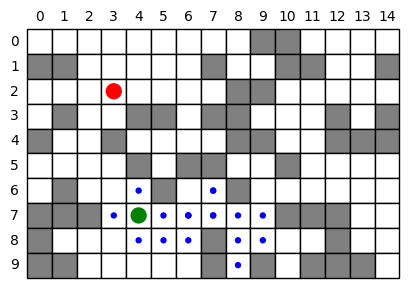

12 (6, 4) [(9, 8), (8, 8), (7, 8), (7, 7), (7, 6), (7, 5), (7, 4)]


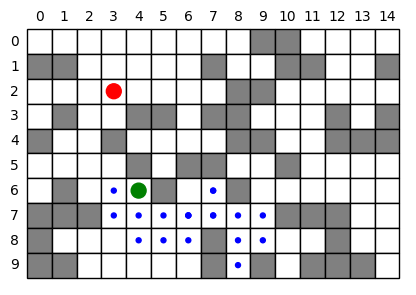

12 (6, 3) [(9, 8), (8, 8), (7, 8), (7, 7), (7, 6), (7, 5), (7, 4), (6, 4)]


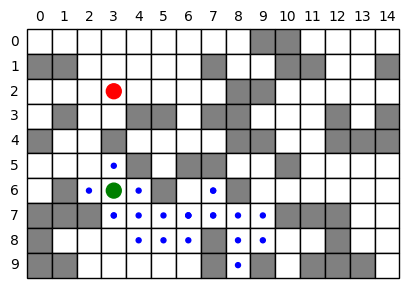

12 (5, 3) [(9, 8), (8, 8), (7, 8), (7, 7), (7, 6), (7, 5), (7, 4), (6, 4), (6, 3)]


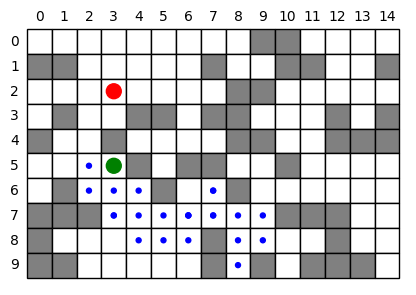

12 (7, 3) [(9, 8), (8, 8), (7, 8), (7, 7), (7, 6), (7, 5), (7, 4)]


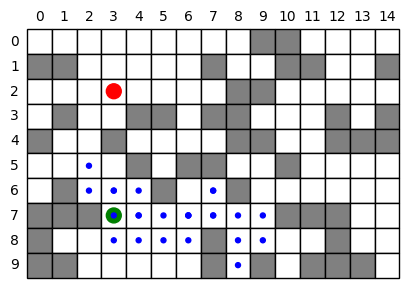

12 (6, 3) [(9, 8), (8, 8), (7, 8), (7, 7), (7, 6), (7, 5), (7, 4), (7, 3)]


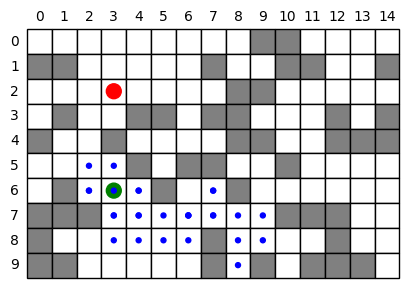

12 (5, 3) [(9, 8), (8, 8), (7, 8), (7, 7), (7, 6), (7, 5), (7, 4), (7, 3), (6, 3)]


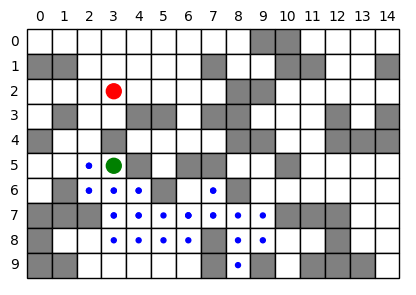

14 (5, 2) [(9, 8), (8, 8), (7, 8), (7, 7), (7, 6), (7, 5), (7, 4), (6, 4), (6, 3), (5, 3)]


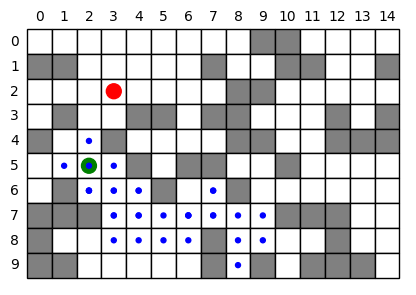

14 (4, 2) [(9, 8), (8, 8), (7, 8), (7, 7), (7, 6), (7, 5), (7, 4), (6, 4), (6, 3), (5, 3), (5, 2)]


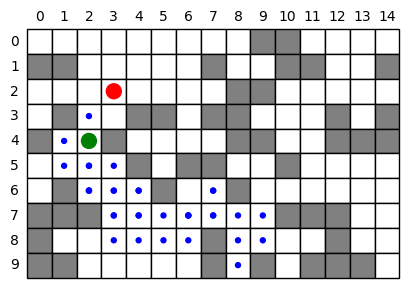

14 (3, 2) [(9, 8), (8, 8), (7, 8), (7, 7), (7, 6), (7, 5), (7, 4), (6, 4), (6, 3), (5, 3), (5, 2), (4, 2)]


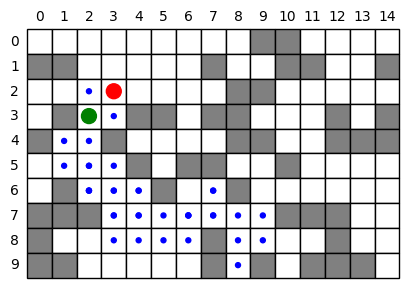

14 (2, 2) [(9, 8), (8, 8), (7, 8), (7, 7), (7, 6), (7, 5), (7, 4), (6, 4), (6, 3), (5, 3), (5, 2), (4, 2), (3, 2)]


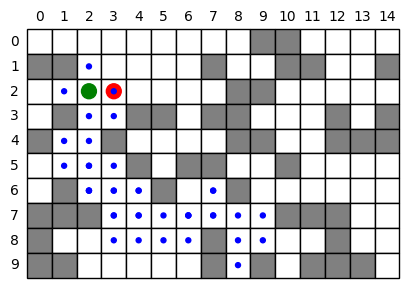

14 (2, 3) [(9, 8), (8, 8), (7, 8), (7, 7), (7, 6), (7, 5), (7, 4), (6, 4), (6, 3), (5, 3), (5, 2), (4, 2), (3, 2), (2, 2)]


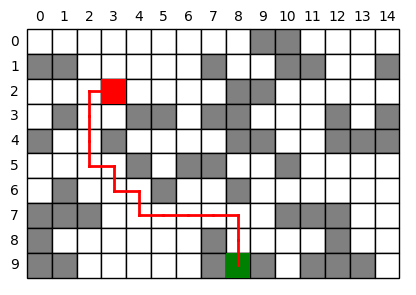

In [ ]:
path = astar(a, start, end)
fig, ax = plt.subplots(figsize=(figure_size, figure_size))
draw_path(a, path, ax)
plt.show()


## Compare Search Strategies

- Replace the heuristic by zero: the priority becomes accumulated cost, as in UCS.
- Compare Manhattan distance at the start with the returned path length. Where do obstacles create the difference?
- Count repeated positions in the printed trace. What information would a best-cost dictionary retain?
- Why is ranking only by the heuristic greedy best-first search rather than A*?

<details class="notebook-answers">
<summary>Answers and discussion</summary>

1. **Zero heuristic gives UCS priorities.** With `h = 0`, every entry is ranked by its accumulated cost `g`. With these unit-cost moves, that is also a depth ordering. However, this implementation still stores repeated paths, unlike the state-deduplicating UCS implementation in the other notebook.
2. **The saved route uses two extra moves.** The start is `(9, 8)` and the goal is `(2, 3)`, so Manhattan distance is `7 + 5 = 12`. The returned route contains 15 cells, or 14 moves. The obstacle-avoiding route reaches column 2 before returning to column 3; this detour accounts for the difference.
3. **Three expansions repeat a previously popped position.** Among the 21 printed removals, `(6, 6)`, `(6, 3)`, and `(5, 3)` each appear twice. A `best_g` dictionary would retain the cheapest discovered cost for each position. Only an improving route should add a new entry; on removal, skip an entry whose cost is worse than the recorded best.
4. **Greedy search ignores the cost already paid.** Ranking only by `h` prefers whichever state appears closest to the goal, even if getting there was expensive. A* ranks by `g + h`, accounting for the whole estimated route cost. An admissible heuristic does not make greedy best-first search optimal.

</details>

**Takeaway:** a heuristic guides search without replacing path cost. Avoiding repeated inferior paths is a separate implementation responsibility.
